<a href="https://colab.research.google.com/github/4cekay/B101-Group2-NLP-Project/blob/backup-points/Troubleshooting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numpy torch datasets transformers sentencepiece protobuf accelerate evaluate tensorboard scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00


In [1]:
import os
import pandas as pd
import numpy as np
import evaluate
from datasets import Dataset, DatasetDict, load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, IntervalStrategy, EarlyStoppingCallback
import torch
from sklearn.model_selection import train_test_split
import huggingface_hub
from collections import Counter
from sklearn.metrics import roc_curve, auc, roc_auc_score, f1_score, confusion_matrix, precision_recall_curve, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
import json


# from checkpoint

In [2]:
# 1. Load the final saved model + tokenizer
checkpoint_dir_1 = "./runs/deberta_v3_interpolate_test_v2/checkpoint-650"   # or your groupmate’s saved folder
tokenizer = AutoTokenizer.from_pretrained(checkpoint_dir_1)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint_dir, dtype=torch.float32)
model.eval()

# 2. Load your evaluation set
external_df = pd.read_csv("./dataset/formal_val_1350.csv", encoding="utf-8")
external_dataset = Dataset.from_pandas(external_df)

# 3. Tokenize with the same settings used in training
MAX_LENGTH = 350
def tokenize(example):
    tokenized = tokenizer(
        example["sample_text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )
    tokenized["labels"] = example["AI_label"]
    return tokenized

tokenized_eval_dataset = external_dataset.map(
    tokenize,
    batched=True,
    remove_columns=external_dataset.column_names
)

# 4. Create a minimal Trainer for evaluation
eval_args = TrainingArguments(
    output_dir="./tmp_eval",
    per_device_eval_batch_size=16,
    report_to="none"
)

eval_trainer = Trainer(
    model=model,
    args=eval_args,
)

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

Map:   0%|          | 0/1350 [00:00<?, ? examples/s]

In [4]:
# 5. Run prediction
preds_output = eval_trainer.predict(tokenized_eval_dataset)
logits = preds_output.predictions
labels = preds_output.label_ids

probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
prob_ai = probs[:, 1]  # probability of AI-generated
predicted_classes = np.argmax(logits, axis=-1)

# 6. Print metrics
print("True label distribution:", Counter(labels.tolist()))
print("Predicted label distribution:", Counter(predicted_classes.tolist()))
print("AUC:", roc_auc_score(labels, prob_ai))
print("F1:", f1_score(labels, predicted_classes))
print("Confusion matrix:\n", confusion_matrix(labels, predicted_classes))


True label distribution: Counter({0: 675, 1: 675})
Predicted label distribution: Counter({0: 1350})
AUC: 0.10258655692729766
F1: 0.0
Confusion matrix:
 [[675   0]
 [675   0]]


# fresh saved objects, local

In [5]:
external_df = pd.read_csv("./dataset/formal_val_1350.csv", encoding="utf-8")
external_dataset = Dataset.from_pandas(external_df)

checkpoint_dir_1 = "./runs/deberta_v3_interpolate_test_v2/checkpoint-650"   # or your groupmate’s saved folder
tokenizer = AutoTokenizer.from_pretrained(checkpoint_dir_1)

In [6]:
checkpoint_dir = r"C:\temp\decisive_check"
tokenizer2 = AutoTokenizer.from_pretrained(checkpoint_dir)
model2 = AutoModelForSequenceClassification.from_pretrained(checkpoint_dir, dtype=torch.float32)
model2.eval()

# sanity check: do the two tokenizers actually agree?
test_text = external_df["sample_text"].iloc[0]
print("original notebook tokenizer:", tokenizer(test_text)["input_ids"][:15])
print("reloaded tokenizer:        ", tokenizer2(test_text)["input_ids"][:15])
# any mismatch here is your answer on the tokenizer question, immediately

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

original notebook tokenizer: [5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
reloaded tokenizer:         [1, 1289, 651, 1738, 265, 598, 334, 264, 374, 288, 425, 261, 273, 4213, 770]


In [9]:
# using ONLY tokenizer2 / model2 — the ones you already confirmed are healthy

def tokenize(example):
    tokenized = tokenizer2(
        example["sample_text"],
        truncation=True,
        padding="max_length",
        max_length=350
    )
    tokenized["labels"] = example["AI_label"]
    return tokenized

tokenized_eval_dataset_v2 = external_dataset.map(
    tokenize,
    batched=True,
    remove_columns=external_dataset.column_names
)

eval_args = TrainingArguments(output_dir="./tmp_eval2", per_device_eval_batch_size=16, report_to="none")
eval_trainer2 = Trainer(model=model2, args=eval_args)

preds_output = eval_trainer2.predict(tokenized_eval_dataset_v2)
logits = preds_output.predictions
labels = preds_output.label_ids
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
prob_ai = probs[:, 1]
predicted_classes = np.argmax(logits, axis=-1)

print("True label distribution:", Counter(labels.tolist()))
print("Predicted label distribution:", Counter(predicted_classes.tolist()))
print("AUC:", roc_auc_score(labels, prob_ai))
print("F1:", f1_score(labels, predicted_classes))
print("Confusion matrix:\n", confusion_matrix(labels, predicted_classes))

Map:   0%|          | 0/1350 [00:00<?, ? examples/s]

True label distribution: Counter({0: 675, 1: 675})
Predicted label distribution: Counter({1: 678, 0: 672})
AUC: 0.9999736625514404
F1: 0.9977827050997783
Confusion matrix:
 [[672   3]
 [  0 675]]


# from main notebook

## training setup

In [ ]:
# --- step budget breakdown, from actual split sizes ---
train_size = len(tokenized_dataset["train"])   # expect ~3780 for a 70% split of 5400
batch_size = 16
steps_per_epoch = -(-train_size // batch_size)  # ceil division

num_train_epochs = 5
total_steps = steps_per_epoch * num_train_epochs

eval_steps = max(50, steps_per_epoch // 6)          # ~6 evals per epoch
warmup_steps = int(0.06 * total_steps)              # 6% warmup, proportional not borrowed
patience_evals = max(4, -(-int(1.5 * steps_per_epoch) // eval_steps))  # >=1.5 epochs runway

print(f"train_size={train_size}")
print(f"steps_per_epoch={steps_per_epoch}")
print(f"total_steps={total_steps}")
print(f"eval_steps={eval_steps}")
print(f"warmup_steps={warmup_steps}")
print(f"patience_evals={patience_evals}  (guarantees {patience_evals*eval_steps} steps runway)")

# expected, for train_size ≈ 3780, batch_size=16:
#   steps_per_epoch ≈ 237
#   total_steps (5 epochs) ≈ 1185
#   eval_steps ≈ 50
#   warmup_steps ≈ 71
#   patience_evals ≈ 8  (400 steps guaranteed runway)

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "microsoft/deberta-v3-small",
    num_labels=2,
    id2label={0: "Human-Written", 1: "AI-Generated"},
    label2id={"Human-Written": 0, "AI-Generated": 1},
    dtype=torch.float32,
)

os.environ["TENSORBOARD_LOGGING_DIR"] = "./logs/interpolate_test_v2"

final_training_args = TrainingArguments(
    seed=42,
    output_dir="./runs/deberta_v3_interpolate_test_v2",
    report_to="tensorboard",

    num_train_epochs=num_train_epochs,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=32,


    learning_rate=2e-5,
    weight_decay=0.01,
    lr_scheduler_type="linear",
    warmup_steps=warmup_steps,
    label_smoothing_factor=0.0, # off, to isolate the eval/loss drift question

    optim="adamw_torch_fused" if torch.cuda.is_available() else "adamw_torch",
    max_grad_norm=1.0,

    fp16=False,
    bf16=torch.cuda.is_bf16_supported(),

    eval_strategy="steps",
    eval_steps=eval_steps,
    save_strategy="steps",
    save_steps=eval_steps,
    save_total_limit=1,
    logging_steps=15,

    metric_for_best_model="accuracy",
    greater_is_better=True,
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=final_training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["val"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=patience_evals)]
)

optuna setup:

TrainOutput(global_step=450, training_loss=0.30206947088241576, metrics={'train_runtime': 169.8306, 'train_samples_per_second': 66.772, 'train_steps_per_second': 4.187, 'total_flos': 650924516743200.0, 'train_loss': 0.30206947088241576, 'epoch': 1.8987341772151898})

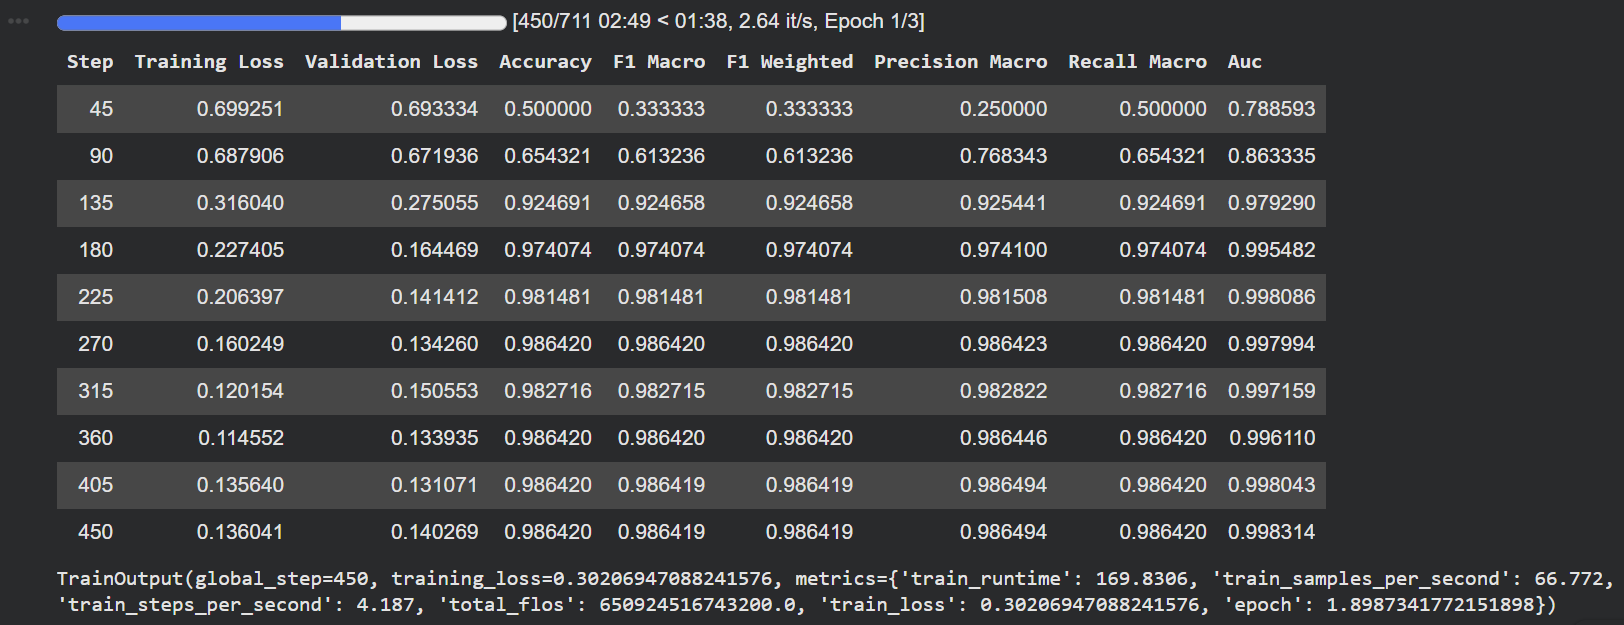

setup #2:

TrainOutput(global_step=1050, training_loss=0.06908108162738028, metrics={'train_runtime': 378.0908, 'train_samples_per_second': 49.988, 'train_steps_per_second': 3.134, 'total_flos': 1517012730172800.0, 'train_loss': 0.06908108162738028, 'epoch': 4.430379746835443})

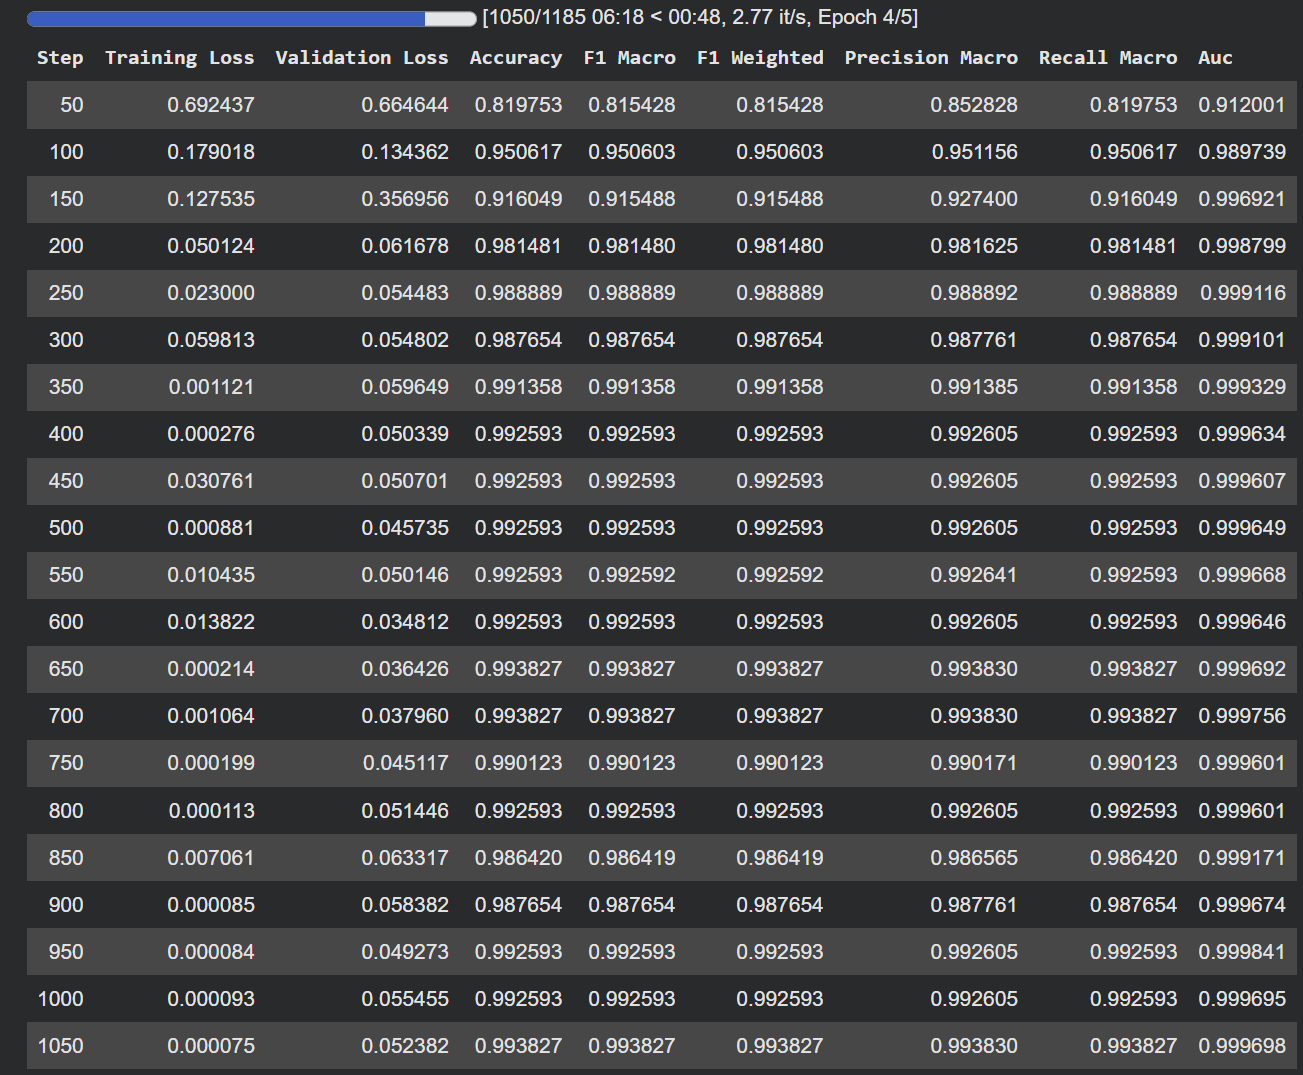

In [ ]:
# immediately after training, evaluate using THIS trainer object explicitly —
# don't reload from disk, don't reuse a trainer from another cell
test_preds = trainer.predict(tokenized_clean_dataset)
test_logits = test_preds.predictions
test_labels = test_preds.label_ids
test_probs = torch.softmax(torch.tensor(test_logits), dim=-1).numpy()[:, 1]
test_preds_class = np.argmax(test_logits, axis=-1)

print("True label distribution:", Counter(test_labels.tolist()))
print("Predicted label distribution:", Counter(test_preds_class.tolist()))
print("AUC:", roc_auc_score(test_labels, test_probs))
print("F1:", f1_score(test_labels, test_preds_class))
print("Confusion matrix:\n", confusion_matrix(test_labels, test_preds_class))


original:
True label distribution: Counter({0: 405, 1: 405})
Predicted label distribution: Counter({1: 410, 0: 400})
AUC: 0.9998780673677793
F1: 0.9914110429447853
Confusion matrix:
 [[399   6]
 [  1 404]]

## fresh trainer results

original:

Subtype: abstract
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       135
           1     1.0000    1.0000    1.0000       135

    accuracy                         1.0000       270
   macro avg     1.0000    1.0000    1.0000       270
weighted avg     1.0000    1.0000    1.0000       270

AUC: 0.9999999999999999
----------------------------------------
Subtype: email
              precision    recall  f1-score   support

           0     0.9922    0.9697    0.9808       132
           1     0.9710    0.9926    0.9817       135

    accuracy                         0.9813       267
   macro avg     0.9816    0.9811    0.9813       267
weighted avg     0.9815    0.9813    0.9813       267

AUC: 0.9990460157126824
----------------------------------------
Subtype: news
              precision    recall  f1-score   support

           0     1.0000    0.9852    0.9925       135
           1     0.9854    1.0000    0.9926       135

    accuracy                         0.9926       270
   macro avg     0.9927    0.9926    0.9926       270
weighted avg     0.9927    0.9926    0.9926       270

AUC: 1.0
----------------------------------------

In [ ]:
external_df = external_df.reset_index(drop=True)

external_df["label"] = external_test_labels
external_df["pred"] = external_test_preds_class
external_df["prob_ai"] = external_test_probs

In [ ]:
external_test_preds = trainer.predict(tokenized_external_dataset)

external_test_logits = external_test_preds.predictions
external_test_labels = external_test_preds.label_ids

external_test_probs = torch.softmax(
    torch.tensor(external_test_logits), dim=-1
).numpy()[:, 1]

external_test_preds_class = np.argmax(external_test_logits, axis=-1)

print("True label distribution:", Counter(external_test_labels.tolist()))
print("Predicted label distribution:", Counter(external_test_preds_class.tolist()))
print("AUC:", roc_auc_score(external_test_labels, external_test_probs))
print("F1:", f1_score(external_test_labels, external_test_preds_class))
print("Confusion matrix:\n", confusion_matrix(external_test_labels, external_test_preds_class))

True label distribution: Counter({0: 675, 1: 675})
Predicted label distribution: Counter({1: 678, 0: 672})
AUC: 0.9999736625514404
F1: 0.9977827050997783
Confusion matrix:
 [[672   3]
 [  0 675]]

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

for subtype, group in clean_test_df.groupby('sub-type'):
    print("Subtype:", subtype)
    print(classification_report(group['AI_label'], group['pred'], digits=4))
    try:
        print("AUC:", roc_auc_score(group['AI_label'], group['prob_ai']))
    except ValueError:
        print("AUC: not computable (single class present)")
    print("-"*40)

Subtype: business
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        26
           1     1.0000    1.0000    1.0000        92

    accuracy                         1.0000       118
   macro avg     1.0000    1.0000    1.0000       118
weighted avg     1.0000    1.0000    1.0000       118

AUC: 1.0
----------------------------------------
Subtype: essay
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        14
           1     1.0000    1.0000    1.0000       405

    accuracy                         1.0000       419
   macro avg     1.0000    1.0000    1.0000       419
weighted avg     1.0000    1.0000    1.0000       419

AUC: 1.0
----------------------------------------
Subtype: letter
              precision    recall  f1-score   support

           0     1.0000    0.9946    0.9973       560
           1     0.9670    1.0000    0.9832        88

    accuracy                         0.9954       648
   macro avg     0.9835    0.9973    0.9903       648
weighted avg     0.9955    0.9954    0.9954       648

AUC: 0.9999797077922078
----------------------------------------
Subtype: nonfiction
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        75
           1     1.0000    1.0000    1.0000        90

    accuracy                         1.0000       165
   macro avg     1.0000    1.0000    1.0000       165
weighted avg     1.0000    1.0000    1.0000       165

AUC: 1.0
----------------------------------------

## cleaned dupes

In [ ]:
def hash_text(s):
    return hashlib.md5(s.encode('utf-8')).hexdigest()

# Assume you have pandas DataFrames: train_df, val_df, test_df with a text column named 'text'
train_hashes = set(train_df['sample_text'].apply(hash_text).tolist())
test_df['text_hash'] = test_df['sample_text'].apply(hash_text)

# Find duplicates in test that appear in train
dups_mask = test_df['text_hash'].isin(train_hashes)
print("Duplicates in test that appear in train:", dups_mask.sum())

# Show examples
print(test_df[dups_mask][['sample_text']].head(10).to_dict(orient='records'))

# Option A: remove duplicates from test (recommended)
clean_test_df = test_df[~dups_mask].reset_index(drop=True)
print("Clean test size:", len(clean_test_df))

# Option B: remove duplicates from train (alternative)
# clean_train_df = train_df[~train_df['text'].apply(hash_text).isin(set(test_df['text_hash']))]


# for troubleshooting

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

# TF-IDF last resort comparison

pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,2))),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# Fit on train split
pipe.fit(train_df['sample_text'], train_df['AI_label'])

# Predict on test split
preds = pipe.predict(test_df['sample_text'])
probs = pipe.predict_proba(test_df['sample_text'])[:,1]

print("Baseline TF-IDF + Logistic Regression Results:")
print(classification_report(test_df['AI_label'], preds))
print("AUC:", roc_auc_score(test_df['AI_label'], probs))

Baseline TF-IDF + Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       405
           1       0.98      0.96      0.97       405

    accuracy                           0.97       810
   macro avg       0.97      0.97      0.97       810
weighted avg       0.97      0.97      0.97       810

AUC: 0.9941533302850175

In [ ]:
seeds = [42, 7, 1234]
results = {}
for s in seeds:
    final_training_args.seed = s
    # re-init model and trainer here (fresh model weights)
    model = AutoModelForSequenceClassification.from_pretrained("microsoft/deberta-v3-small", num_labels=2, dtype=torch.float32)
    trainer = Trainer(model=model, args=final_training_args, train_dataset=tokenized_dataset["train"], eval_dataset=tokenized_dataset["validation"], compute_metrics=compute_metrics)
    trainer.train()
    preds = trainer.predict(tokenized_dataset["test"])
    probs = torch.softmax(torch.tensor(preds.predictions), dim=-1).numpy()[:,1]
    preds_class = np.argmax(preds.predictions, axis=-1)
    results[s] = {"auc": roc_auc_score(preds.label_ids, probs), "f1": f1_score(preds.label_ids, preds_class)}
print(results)
